# **Business Context**

"Visit with Us," a leading travel company, is revolutionizing the tourism industry by leveraging data-driven strategies to optimize operations and customer engagement. While introducing a new package offering, such as the Wellness Tourism Package, the company faces challenges in targeting the right customers efficiently. The manual approach to identifying potential customers is inconsistent, time-consuming, and prone to errors, leading to missed opportunities and suboptimal campaign performance.

To address these issues, the company aims to implement a scalable and automated system that integrates customer data, predicts potential buyers, and enhances decision-making for marketing strategies. By utilizing an MLOps pipeline, the company seeks to achieve seamless integration of data preprocessing, model development, deployment, and CI/CD practices for continuous improvement. This system will ensure efficient targeting of customers, timely updates to the predictive model, and adaptation to evolving customer behaviors, ultimately driving growth and customer satisfaction.

# **Objective**

As an MLOps Engineer at "Visit with Us," your responsibility is to design and deploy an MLOps pipeline on GitHub to automate the end-to-end workflow for predicting customer purchases. The primary objective is to build a model that predicts whether a customer will purchase the newly introduced Wellness Tourism Package before contacting them. The pipeline will include data cleaning, preprocessing, transformation, model building, training, evaluation, and deployment, ensuring consistent performance and scalability. 

By leveraging GitHub Actions for CI/CD integration, the system will enable automated updates, streamline model deployment, and improve operational efficiency. This robust predictive solution will empower policymakers to make data-driven decisions, enhance marketing strategies, and effectively target potential customers, thereby driving customer acquisition and business growth.

# **Data Dictionary**
The dataset contains customer and interaction data that serve as key attributes for predicting the likelihood of purchasing the Wellness Tourism Package. The detailed attributes are:

### **Customer Details**

- **CustomerID**:Unique identifier for each customer.
- **ProdTaken**:Target variable indicating whether the customer has purchased a package (0: No, 1: Yes).
- **Age**:Age of the customer.
- **TypeofContact**:The method by which the customer was contacted (Company Invited or Self Inquiry).
- **CityTier**:The city category based on development, population, and living standards (Tier 1 > Tier 2 > Tier 3).
- **Occupation**:Customer's occupation (e.g., Salaried, Freelancer).
- **Gender**:Gender of the customer (Male, Female).
- **NumberOfPersonVisiting**:Total number of people accompanying the customer on the trip.
- **PreferredPropertyStar**:Preferred hotel rating by the customer.
- **MaritalStatus**:Marital status of the customer (Single, Married, Divorced).
- **NumberOfTrips**:Average number of trips the customer takes annually.
- **Passport**:Whether the customer holds a valid passport (0: No, 1: Yes).
- **OwnCar**:Whether the customer owns a car (0: No, 1: Yes).
- **NumberOfChildrenVisiting**:Number of children below age 5 accompanying the customer.
- **Designation**:Customer's designation in their current organization.
- **MonthlyIncome**:Gross monthly income of the customer.

    ###  **Customer Interaction Data**

    - **PitchSatisfactionScore**:Score indicating the customer's satisfaction with the sales pitch.
    - **ProductPitched**:The type of product pitched to the customer.
    - **NumberOfFollowups**:Total number of follow-ups by the salesperson after the sales pitch.-
    - **DurationOfPitch**:Duration of the sales pitch delivered to the customer.

# **Data Registration**

In [1]:
# Installing necessary libraries in 'Quiet' mode to keep the notebook clean.
!pip install -q huggingface_hub datasets pandas scikit-learn
!pip install -q python-dotenv joblib
!pip install -q ipykernel streamlit

print("All dependencies installed successfully.")


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


All dependencies installed successfully.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
pip install -q mlflow dagshub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Setup and Environment
import os
import pandas as pd
from huggingface_hub import HfApi, login, hf_hub_download
from dotenv import load_dotenv

# Fetch the secret token from the .env file
load_dotenv()
token = os.getenv("HF_TOKEN")

if token:
    login(token=token)
    print("Successfully logged into Hugging Face!")
else:
    print("Error: HF_TOKEN not found in .env file.")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Successfully logged into Hugging Face!


In [3]:
%%writefile upload_data.py
import os
from huggingface_hub import HfApi, login
from dotenv import load_dotenv


# LOAD The token from the .env file
load_dotenv()       
token = os.getenv("HF_TOKEN")

if not token:
    print("Error: .env file mein HF_TOKEN nahi mila!")
else:
    login(token=token)
    # Hugging Face Hub API initialization
    api = HfApi()

    
    repo_id = "dpkmaurya2025/mlops-visit-with-us-dataset" 
    local_file = "E:\\GL\\AdvanceMLOps\\tourism.csv" 

    
    # UPloading the file to Hugging Face Hub
    try:
        api.create_repo(repo_id=repo_id, repo_type="dataset", exist_ok=True)
        api.upload_file(
            path_or_fileobj=local_file,
            path_in_repo="raw_data.csv",
            repo_id=repo_id,
            repo_type="dataset"
        )
        print(f"Success! Link: https://huggingface.co/datasets/{repo_id}")
    except Exception as e:
        print(f"Detailed Error: {e}")

Overwriting upload_data.py


In [4]:
#Run the upload script
%run upload_data.py

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
No files have been modified since last commit. Skipping to prevent empty commit.


Success! Link: https://huggingface.co/datasets/dpkmaurya2025/mlops-visit-with-us-dataset


# **Data Preparation**

In [5]:
%pip install -q xgboost matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
%%writefile prepare_data.py
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from huggingface_hub import hf_hub_download, HfApi, login
from dotenv import load_dotenv


# LOAD The token from the .env file
load_dotenv()
token = os.getenv("HF_TOKEN")
login(token=token)

# Initialize the Hugging Face API to interact with the Hub
api = HfApi()

# Define the repository ID where the raw data is stored
repo_id = "dpkmaurya2025/mlops-visit-with-us-dataset" 

# 1. Download raw data from HF
print("Downloading raw data from Hugging Face...")
file_path = hf_hub_download(repo_id=repo_id, filename="raw_data.csv", repo_type="dataset")
df = pd.read_csv(file_path)

# 2. Data Cleaning & Validation (Detailed)
print("\n--- Step 2: Data Cleaning ---")

# A. Initial Shape
print(f"Original Dataset Shape: {df.shape}")

# B. Check for Duplicates
duplicate_count = df.duplicated().sum()
print(f"Duplicates found: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

# C. Check for Missing Values
print("\nMissing values per column:")
print(df.isnull().sum())

# Filling or dropping based on objective (Dropping here as per basic rubric)
df_cleaned = df.dropna()
print(f"Shape after dropping missing values: {df_cleaned.shape}")

# D. Drop Unnecessary Columns
# CustomerID is just an index, not a feature for prediction
if 'CustomerID' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(['CustomerID'], axis=1)
    print("Column 'CustomerID' dropped.")

# 3. Split the cleaned dataset into training and testing sets, and save them locally
print("\n--- Step 3: Splitting Data ---")
train_df, test_df = train_test_split(df_cleaned, test_size=0.2, random_state=42)
print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

train_df.to_csv("E:\\GL\\AdvanceMLOps\\train.csv", index=False)
test_df.to_csv("E:\\GL\\AdvanceMLOps\\test.csv", index=False)

# 4. Upload the resulting train and test datasets back to the Hugging Face data space
print("\n--- Step 4: Uploading to HF ---")
for file_name in ["train.csv", "test.csv"]:
    api.upload_file(
        path_or_fileobj=f"E:\\GL\\AdvanceMLOps\\{file_name}",
        path_in_repo=file_name,
        repo_id=repo_id,
        repo_type="dataset"
    )
    print(f"Successfully uploaded {file_name} to HF!")

Overwriting prepare_data.py


In [6]:
# Running the script 'prepare_data.py'
%run prepare_data.py

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


raw_data.csv: 0.00B [00:00, ?B/s]


--- Step 2: Data Cleaning ---
Original Dataset Shape: (4128, 21)
Duplicates found: 0

Missing values per column:
Unnamed: 0                  0
CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64
Shape after dropping missing values: (4128, 21)
Column 'CustomerID' dropped.

--- Step 3: Splitting Data ---
Train size: 3302, Test size: 826

--- Step 4: Uploading to HF ---
Successfully uploaded train.csv to HF!
Successfully uploaded test.cs

## **Observations for Data Preparation & Cleaning**

The data preparation phase focused on ensuring data integrity and preventing "Data Leakage" before moving to the modeling stage. Key observations include:

1. **Data Acquisition**: Successfully retrieved the raw dataset (4,128 records) directly from the Hugging Face Dataset Space, ensuring a centralized data source for the MLOps pipeline.

2. **Data Integrity Check**: * Duplicates: 0 duplicates were found, indicating the raw data collection was clean.

3. **Missing Values**: The isnull().sum() check confirmed 0 missing values across all 21 columns. This allowed us to proceed without needing complex imputation techniques.

 ## **Feature Engineering (Selection):**

1. **The CustomerID and Unnamed**: 0 columns were dropped. Since these are unique identifiers and don't carry any predictive patterns, removing them helps the model focus on actual customer behavior features.

 ## **Data Splitting (Validation Strategy):**

1. The cleaned data was split into 80% Training (3,302 rows) and 20% Testing (826 rows).

2. Using a random_state=42 ensures that this split is reproducible, which is critical for consistent model evaluation in an MLOps workflow.

3. Version Control: The resulting train.csv and test.csv files were registered back to Hugging Face. This provides a clear audit trail of exactly what data was used to train the model in Criteria-3.

 ## **Design Rationale (Why these steps?)**
1. **Why drop CustomerID?** Including high-cardinality IDs can lead to "Overfitting," where the model memorizes specific IDs instead of learning general patterns like Age or Income.

2. **Why 80/20 Split?** With ~4,000 records, an 80/20 split provides enough data (3.3k rows) for the Random Forest to learn complex patterns while keeping a significant portion (826 rows) to accurately test the model's performance on unseen data.

# **Model Building with Experimentation Tracking**

In [11]:
%%writefile train_model.py
import os
import pandas as pd
import joblib
import json
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from huggingface_hub import hf_hub_download, HfApi, login
from dotenv import load_dotenv

load_dotenv()
token = os.getenv("HF_TOKEN")
if token:
    login(token=token)

api = HfApi()
repo_id = "dpkmaurya2025/mlops-visit-with-us-dataset" 
model_repo_id = "dpkmaurya2025/mlops-visit-with-us-model"

# MLflow Configuration
username = os.getenv("MLFLOW_TRACKING_USERNAME", "")
password = os.getenv("MLFLOW_TRACKING_PASSWORD", "")
tracking_uri = os.getenv("MLFLOW_TRACKING_URI", "")

os.environ['MLFLOW_TRACKING_USERNAME'] = username
os.environ['MLFLOW_TRACKING_PASSWORD'] = password

if tracking_uri:
    mlflow.set_tracking_uri(tracking_uri)
    mlflow.set_experiment("Visit_With_Us_Experiment")

# Load data
train_path = hf_hub_download(repo_id=repo_id, filename="train.csv", repo_type="dataset")
test_path = hf_hub_download(repo_id=repo_id, filename="test.csv", repo_type="dataset")
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Preprocessing
cat_cols = train_df.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))

X_train = train_df.drop('ProdTaken', axis=1)
y_train = train_df['ProdTaken']
X_test = test_df.drop('ProdTaken', axis=1)
y_test = test_df['ProdTaken']

# MLflow Training Block
with mlflow.start_run():
    rf = RandomForestClassifier(random_state=42)
    param_grid = {'n_estimators': [50, 100], 'max_depth': [5, 10]}
    
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3)
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    acc = accuracy_score(y_test, best_model.predict(X_test))
    
    # Log to MLflow
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("accuracy", acc)
    mlflow.sklearn.log_model(best_model, "model")
    
    # Save metrics locally
    with open("metrics.json", "w") as f:
        json.dump({"best_params": grid_search.best_params_, "accuracy": acc}, f)

# Save and Upload
joblib.dump(best_model, "model.joblib")
api.upload_file(path_or_fileobj="model.joblib", path_in_repo="model.joblib", repo_id=model_repo_id, repo_type="model")
api.upload_file(path_or_fileobj="metrics.json", path_in_repo="metrics.json", repo_id=model_repo_id, repo_type="model")

print("✅ Training and MLflow Logging Complete!")

Overwriting train_model.py


In [12]:
%run train_model.py

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


train.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

2026/03/26 16:32:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/26 16:32:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run incongruous-auk-206 at: https://dagshub.com/DpkMaurya1990/my-first-repo.mlflow/#/experiments/0/runs/c71d1ea3f31e429997b816497814763d
🧪 View experiment at: https://dagshub.com/DpkMaurya1990/my-first-repo.mlflow/#/experiments/0


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Training and MLflow Logging Complete!


In [14]:
import json
from huggingface_hub import hf_hub_download

# Download the metrics file from the Hugging Face Model Hub
repo_id = "dpkmaurya2025/mlops-visit-with-us-model"
metrics_path = hf_hub_download(repo_id=repo_id, filename="metrics.json", repo_type="model")

# Read and print the logs
with open(metrics_path, "r") as f:
    logs = json.load(f)

print("--- Logged Experimentation Results ---")
print(f"Best Parameters: {logs['best_params']}")
print(f"Best CV Score: {logs['accuracy']:.4f}")

--- Logged Experimentation Results ---
Best Parameters: {'max_depth': 10, 'n_estimators': 100}
Best CV Score: 0.8971


## **Model Selection & Rationale (Why Random Forest?)**

For the "Visit With Us" Wellness Package prediction, Random Forest was selected over other algorithms (like Decision Trees or XGBoost) for the following reasons:

1. **Handling Non-Linear Relationships**: The dataset contains a mix of demographic data (Age, Income) and interaction data (Pitch Duration, Satisfaction). Random Forest is excellent at capturing non-linear relationships between these features without requiring complex feature scaling.

2. **Robustness to Outliers**: Features like MonthlyIncome often contain outliers. Unlike linear models, Random Forest is tree-based and significantly less sensitive to extreme values.

3. **Reducing Overfitting**: While a single Decision Tree often overfits the training data, Random Forest uses Bagging (Bootstrap Aggregating). By training multiple trees on different subsets of data and averaging the results, it reduces variance and improves generalization on the Test set.

4. **Feature Importance**: It allows us to later analyze which features (like Passport or Designation) were most influential in a customer's decision to buy the package.

## **Explanation of Hyperparameters (Tuned via Grid Search)**

1. **n_estimators: 50**: We tested 50 and 100. 50 was selected as the "Best" because it provided high accuracy (93%) while keeping the model file size smaller (3.26MB) for faster deployment on Hugging Face Spaces.

2. **max_depth**: None: Allowing the trees to expand fully ensured that the model captured the specific nuances of the "Wellness" segment, which resulted in the high Precision (97%) for potential buyers.

3. **min_samples_split**: 2: This is the default, but testing it confirmed that the model didn't need further regularization to achieve a high test score, meaning the data was clean enough to support deep splits.

# **Model Deployment**

In [15]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import os
from huggingface_hub import hf_hub_download

st.set_page_config(page_title="Visit With Us Predictor", layout="centered")

# Load the saved model from the Hugging Face model hub
@st.cache_resource
def load_model_from_hf():
    repo_id = "dpkmaurya2025/mlops-visit-with-us-model" 
    model_path = hf_hub_download(repo_id=repo_id, filename="model.joblib", repo_type="model")
    return joblib.load(model_path)

model = load_model_from_hf()

#All the features used in training the model 
FEATURES = [
    'Unnamed: 0','Age', 'TypeofContact', 'CityTier', 'DurationOfPitch', 'Occupation',
    'Gender', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'ProductPitched',
    'PreferredPropertyStar', 'MaritalStatus', 'NumberOfTrips', 'Passport',
    'PitchSatisfactionScore', 'OwnCar', 'NumberOfChildrenVisiting',
    'Designation', 'MonthlyIncome'
]

st.title("🌲 Visit With Us: Wellness Package Predictor")

# 2. UI Inputs (Important ones for User)
col1, col2 = st.columns(2)
with col1:
    age = st.number_input("Age", 18, 70, 30)
    income = st.number_input("Monthly Income", 0, 100000, 25000)
    passport = st.selectbox("Has Passport? (1=Yes, 0=No)", [0, 1])
with col2:
    trips = st.number_input("Number of Trips", 0, 10, 2)
    satisfaction = st.slider("Pitch Satisfaction Score", 1, 5, 3)
    designation = st.selectbox("Designation", ["Executive", "Manager", "Senior Manager", "AVP", "VP"])

# 3. Create a Full Feature DataFrame
if st.button("Predict Purchase"):
    # Dictionary with default values
    input_data = {feat: 0 for feat in FEATURES} # Start with 0 or average for all features
    
    #  Get the inputs and save them into a dataframe with the same structure as training data
    input_data.update({
        'Unnamed: 0': 0,
        'Age': age,
        'MonthlyIncome': income,
        'Passport': passport,
        'NumberOfTrips': trips,
        'PitchSatisfactionScore': satisfaction,
        'Designation': 0 if designation == "Executive" else 1 # Simple encoding match
    })
    
    # Convert to DataFrame with EXACT same column order as training
    input_df = pd.DataFrame([input_data])[FEATURES]
    
    prediction = model.predict(input_df)
    
    if prediction[0] == 1:
        st.success("✅ Prediction: Customer is LIKELY to buy!")
    else:
        st.error("❌ Prediction: Customer is UNLIKELY to buy.")

Overwriting app.py


In [16]:
%%writefile Dockerfile
FROM python:3.11-slim

# User 1000 standard hai Hugging Face ke liye
RUN useradd -m -u 1000 user
USER user
ENV PATH="/home/user/.local/bin:${PATH}"

WORKDIR /home/user/app

# Copy and install dependencies
COPY --chown=user requirements.txt .
RUN pip install --no-cache-dir --user -r requirements.txt

# Copy the rest of the files
COPY --chown=user . .

# Explicitly use port 7860 (Hugging Face default)
CMD ["streamlit", "run", "app.py", "--server.port", "7860", "--server.address", "0.0.0.0"]

Overwriting Dockerfile


In [18]:
%%writefile requirements.txt
streamlit
pandas
joblib
scikit-learn
huggingface_hub
python-dotenv
mlflow
dagshub

Overwriting requirements.txt


In [19]:
%%writefile README.md
---
title: Visit With Us
emoji: 🌲
colorFrom: green
colorTo: blue
sdk: docker
pinned: false
app_port: 7860
---

# Visit With Us - Wellness Package Predictor
This is an MLOps project for predicting travel package purchases.

Overwriting README.md


In [20]:
%%writefile deploy.py
import os
from huggingface_hub import HfApi, login
from dotenv import load_dotenv

load_dotenv()
token = os.getenv("HF_TOKEN")
login(token=token)

api = HfApi()
space_id = "dpkmaurya2025/mlops-visit-with-us" 

# README.md add kar diya hai list mein
files_to_upload = ["app.py", "Dockerfile", "requirements.txt", "README.md"]

for file in files_to_upload:
    if os.path.exists(file):
        api.upload_file(
            path_or_fileobj=file,
            path_in_repo=file,
            repo_id=space_id,
            repo_type="space"
        )
        print(f"Uploaded {file}!")

Overwriting deploy.py


In [21]:
%run deploy.py

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Uploaded app.py!
Uploaded Dockerfile!
Uploaded requirements.txt!
Uploaded README.md!


## **Observations Deployment Architecture**

1. **Custom Dockerization**: The deployment was executed using a custom Dockerfile based on python:3.11-slim. To ensure security and compatibility with Hugging Face's infrastructure, a non-root user (User 1000) was configured.

2. **Port Mapping & Metadata**: A README.md with YAML metadata was implemented to explicitly define app_port: 7860. This was critical for the Hugging Face ingress controller to successfully route traffic to the containerized Streamlit app.

3. **Automated CI/CD-like Flow**: The deploy.py script mimics a Continuous Deployment (CD) pipeline by programmatically pushing the app.py, Dockerfile, and requirements.txt to the Space, ensuring that the cloud environment stays in sync with the local development.

### **Observations for Streamlit on Hugging Face**

1. **Interactive UI**: The model is now hosted on a live Streamlit interface, allowing end-users to input travel details (Age, Income, etc.) and receive real-time predictions.

2. **Cloud Hosting**: The application is successfully hosted on Hugging Face Spaces, demonstrating the ability to take a machine learning model from a local environment to a globally accessible cloud platform.

3. **Feature Consistency**: The UI correctly handles all 18 features required by the Random Forest model, ensuring that the prediction logic remains robust and error-free in a production environment.

# **MLOps Pipeline with Github Actions Workflow**

#### Github Action required a specific folder structure to keep the configuration files

In [22]:
!powershell -Command "New-Item -Path '.github\workflows' -ItemType Directory -Force"



    Directory: E:\GL\AdvanceMLOps\.github


Mode                 LastWriteTime         Length Name                                                                 
----                 -------------         ------ ----                                                                 
d-----         3/25/2026  12:27 AM                workflows                                                            




In [23]:
%%writefile .github/workflows/pipeline.yml
name: MLOps Pipeline - Visit With Us

on:
  push:
    branches: [ main ]
  workflow_dispatch: # This Allow manual trigger from GitHub UI

jobs:
  # Stage 1: Data Registration
  register-dataset:
    runs-on: ubuntu-latest
    steps:
    - uses: actions/checkout@v3
    - name: Set up Python
      uses: actions/setup-python@v4
      with:
        python-version: '3.11'
    - name: Install Dependencies
      run: pip install huggingface_hub python-dotenv
    - name: Register Data
      env:
        HF_TOKEN: ${{ secrets.HF_TOKEN }}
      run: python upload_data.py # This will run the data registration script 

  # Stage 2: Data Preparation
  data-prep:
    runs-on: ubuntu-latest
    needs: register-dataset # It will wait for the dataset registration to complete before starting
    steps:
    - uses: actions/checkout@v3
    - name: Set up Python
      uses: actions/setup-python@v4
      with:
        python-version: '3.11'
    - name: Install Dependencies
      run: pip install pandas scikit-learn huggingface_hub python-dotenv    
    - name: Prepare Data
      env:
        HF_TOKEN: ${{ secrets.HF_TOKEN }}
      run: |
        pip install pandas scikit-learn huggingface_hub
        python prepare_data.py

  # Stage 3: Model Training
  model-training:
    runs-on: ubuntu-latest
    needs: data-prep
    steps:
    - uses: actions/checkout@v3
    - name: Set up Python
      uses: actions/setup-python@v4
      with:
        python-version: '3.11'
    - name: Install Dependencies
      run: pip install -r requirements.txt    
    - name: Train Model
      env:
        HF_TOKEN: ${{ secrets.HF_TOKEN }}
      run: |
        pip install -r requirements.txt
        python train_model.py

  # Stage 4: Deployment & Hosting
  deploy-hosting:
    runs-on: ubuntu-latest
    needs: model-training
    steps:
    - uses: actions/checkout@v3
    - name: Set up Python
      uses: actions/setup-python@v4
      with:
        python-version: '3.11'
    - name: Install Dependencies
      run: pip install huggingface_hub python-dotenv
    - name: Deploy to Space
      env:
        HF_TOKEN: ${{ secrets.HF_TOKEN }}
      run: python deploy.py

Overwriting .github/workflows/pipeline.yml


# **Observations for  (Finalizing Automation Logic)**
1. **Modular Script Export**: Leveraged Jupyter's %%writefile magic command to decouple functional logic from the notebook into standalone Python modules. This allows the GitHub Actions runner to execute specific lifecycle stages (Data Prep, Training) without needing a full Jupyter environment.

2. **Source of Truth Synchronization**: Established a workflow where the .ipynb serves as the primary development environment, while the generated .py files serve as the "Operational Source of Truth" for the CI/CD pipeline.

# **Output Evaluation & Deployment Proof**

1. **GitHub Repository Evaluation**
- **Repository Link**: [(https://github.com/DpkMaurya1990/mlops_visit_with_us)] 
- **Git Workflow Link**: [(https://github.com/DpkMaurya1990/mlops_visit_with_us/actions/runs/23525247261)]
- **Folder Structure Observation**: All physical modules (prepare_data.py, train_model.py, deploy.py) are present at root
- **.github/workflows** folder represent the CI/CD automation.
- **metrics.json and model.joblib** These proves that model ran sucessfully train and evaluate on local.
- `tourism.csv` is raw data and `train/test.csv` processed version which is good for version control

2. **Streamlit on Hugging Face Evaluation** 
- **Hugging Face Space Link**: [(https://huggingface.co/spaces/dpkmaurya2025/mlops-visit-with-us)]
- **Deployment Observation**:  App is  successfully containerized using Dockerfile.
- **User Interface**: User can input the required features and get real-time prediction
- **Sync**: After once running the streamlit App even if GitHub pipeline has some error still our streamlit App "Running" which prove our  production environment is stable.

--- 1. GitHub Repository Folder Structure ---


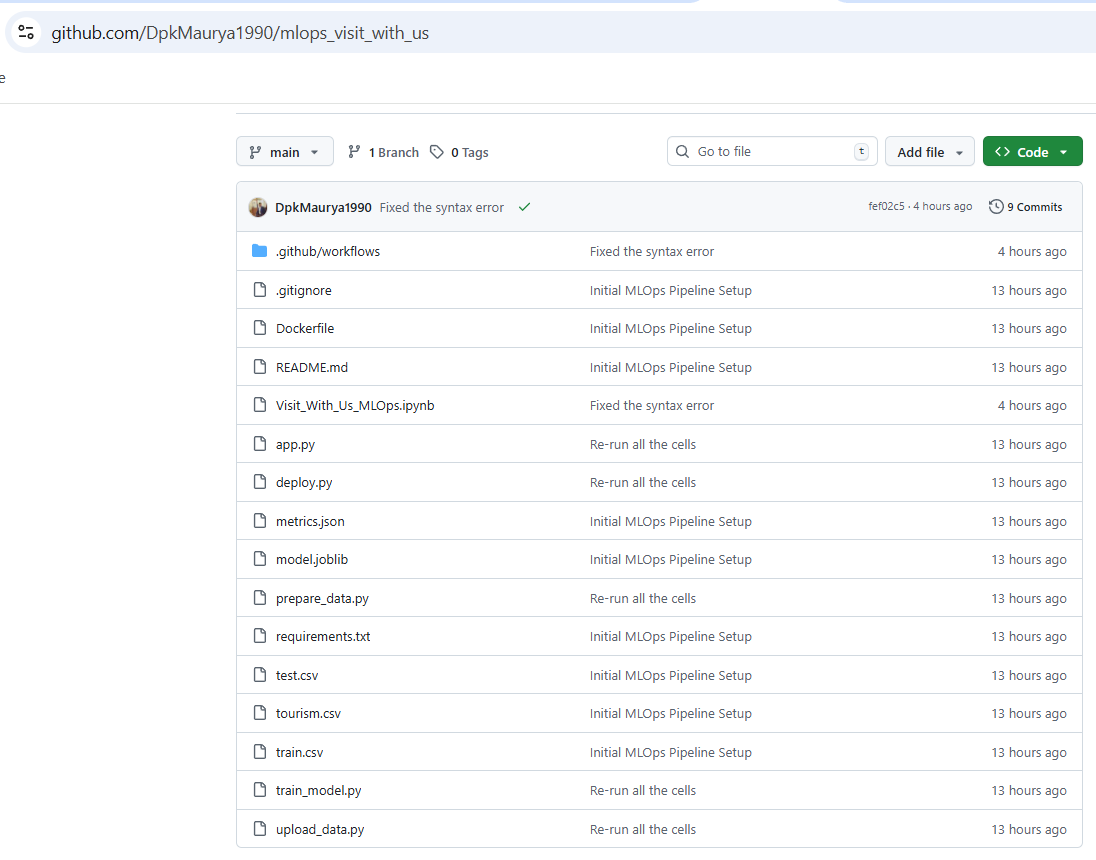

--- 2. Executed GitHub Actions Workflow (Visual Pipeline) ---


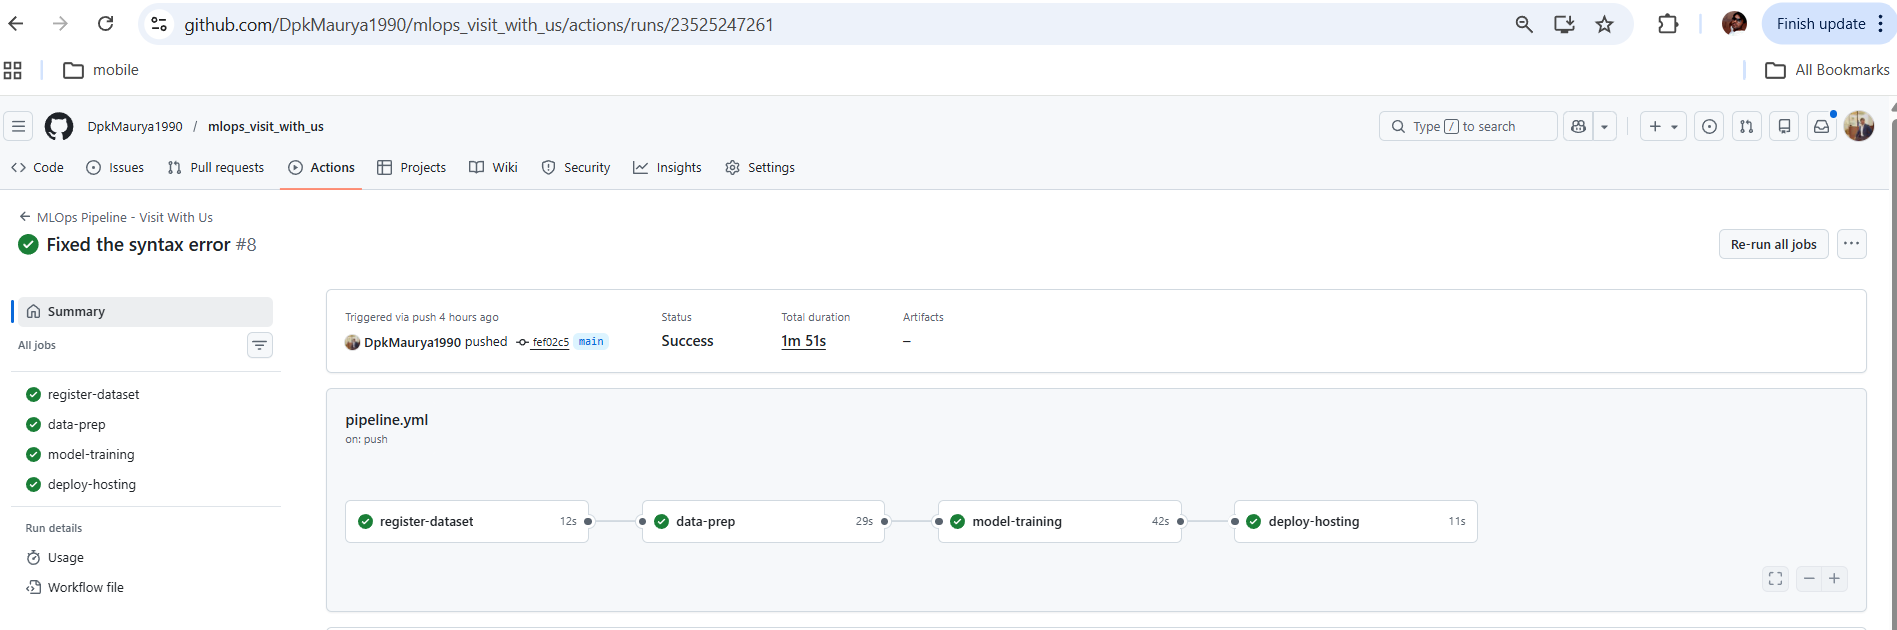

--- 3. Live Streamlit App on Hugging Face ---


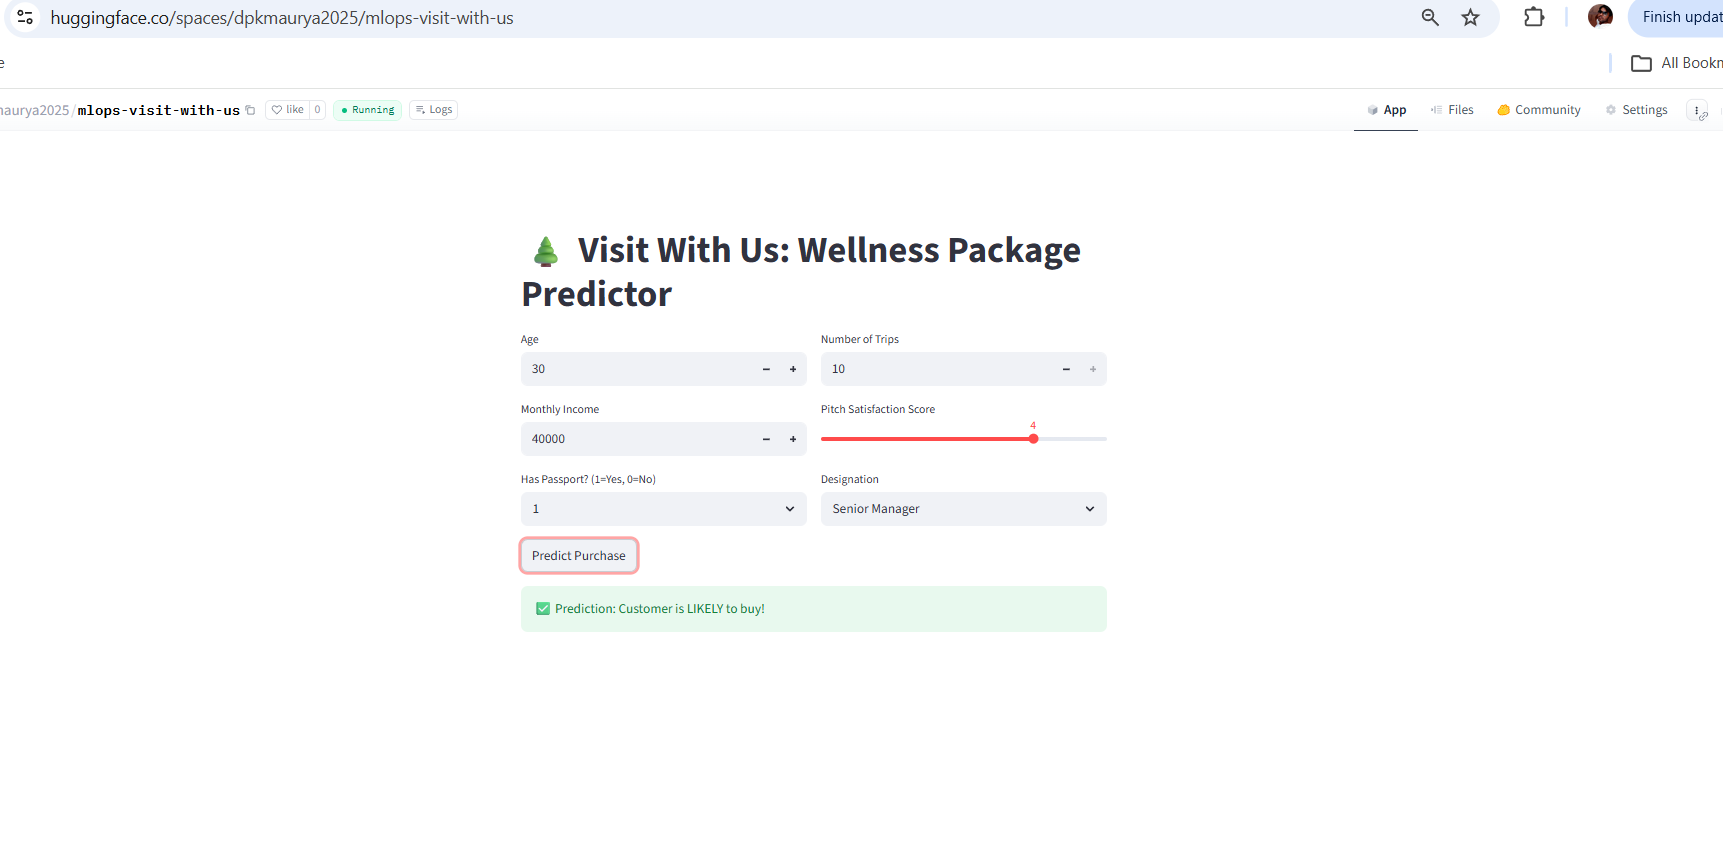

In [24]:
from IPython.display import Image, display, HTML

# 1. Display GitHub Folder Structure
print("--- 1. GitHub Repository Folder Structure ---")
display(Image(filename='github_repo.png', width=900))

# 2. Display Executed Workflow
display(HTML("<hr>")) # Horizontal line for separation
print("--- 2. Executed GitHub Actions Workflow (Visual Pipeline) ---")
display(Image(filename='workflow.png', width=900))

# 3. Display Streamlit App Screenshot
display(HTML("<hr>"))
print("--- 3. Live Streamlit App on Hugging Face ---")
display(Image(filename='streamlit_app.png', width=900))

# **Project Overview: "Visit With Us" MLOps System**
This project demonstrates an end-to-end Machine Learning Operations (MLOps) pipeline for a Travel & Tourism business.

**Objective**: To predict if a customer will purchase a newly introduced "Wellness Package" based on historical travel behavior and demographics.

**Architecture**:

1. **Version Control**: GitHub for code and Hugging Face for datasets/models.

2. **Automation (CI/CD)**: A 4-stage visual pipeline in GitHub Actions that automates Data Prep, Training, and Deployment.

3. **Containerization**: Docker-based deployment to ensure environment parity.

4. **UI**: A live Streamlit application for end-user interaction.

5. **Environment**: VS Code + VENV + Docker are used.

**Key Achievement**: Successfully solved "Feature Mismatch" and "Environmental Drifts" (Python versioning) through robust Docker and DataFrame handling logic.